# **Retail Sales, Purchase, Vendor and Inventory Analysis**

## Objective
The objective of this project is to analyze sales, purchases, vendor invoices, and inventory data to identify revenue drivers, vendor performance, freight cost impact, and inventory efficiency.

## Data Sources
This project uses six datasets:
- Sales
- Purchases
- Purchase Prices
- Vendor Invoice
- Beginning Inventory
- Ending Inventory

## Data Cleaning Performed
- Converted date columns to datetime format
- Converted numeric and financial columns to proper numeric data types
- Rounded financial values to two decimal places
- Checked duplicate rows
- Checked missing values
- Validated sales amount and purchase amount calculations
- Created inventory value columns

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Load all datasets

In [2]:
sales = pd.read_csv("raw_data/sales.csv")
purchases = pd.read_csv("raw_data/purchases.csv")
purchase_prices = pd.read_csv("raw_data/purchase_prices.csv")
vendor_invoice = pd.read_csv("raw_data/vendor_invoice.csv")
begin_inventory = pd.read_csv("raw_data/begin_inventory.csv")
end_inventory = pd.read_csv("raw_data/end_inventory.csv")



## Checking basic shape

In [11]:
datasets = {
    "sales": sales,
    "purchases": purchases,
    "purchase_prices": purchase_prices,
    "vendor_invoice": vendor_invoice,
    "begin_inventory": begin_inventory,
    "end_inventory": end_inventory
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print(df.head())


SALES
Rows: 12825363
Columns: 14
           InventoryId  Store  Brand                 Description        Size  \
0  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
1  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
2  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
3  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
4  1_HARDERSFIELD_1005      1   1005     Maker's Mark Combo Pack  375mL 2 Pk   

   SalesQuantity  SalesDollars  SalesPrice   SalesDate  Volume  \
0              1         16.49       16.49  2024-01-01   750.0   
1              2         32.98       16.49  2024-01-02   750.0   
2              1         16.49       16.49  2024-01-03   750.0   
3              1         14.49       14.49  2024-01-08   750.0   
4              2         69.98       34.99  2024-01-09   375.0   

   Classification  ExciseTax  VendorNo                   VendorName  
0               1 

## Checking Data types

In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()} DATA TYPES")
    print(df.dtypes)


SALES DATA TYPES
InventoryId        object
Store               int64
Brand               int64
Description        object
Size               object
SalesQuantity       int64
SalesDollars      float64
SalesPrice        float64
SalesDate          object
Volume            float64
Classification      int64
ExciseTax         float64
VendorNo            int64
VendorName         object
dtype: object

PURCHASES DATA TYPES
InventoryId        object
Store               int64
Brand               int64
Description        object
Size               object
VendorNumber        int64
VendorName         object
PONumber            int64
PODate             object
ReceivingDate      object
InvoiceDate        object
PayDate            object
PurchasePrice     float64
Quantity            int64
Dollars           float64
Classification      int64
dtype: object

PURCHASE_PRICES DATA TYPES
Brand               int64
Description        object
Price             float64
Size               object
Volume             o

## Convert date columns

In [3]:
sales["SalesDate"] = pd.to_datetime(sales["SalesDate"], errors="coerce")

date_cols_purchases = ["PODate", "ReceivingDate", "InvoiceDate", "PayDate"]
for col in date_cols_purchases:
    purchases[col] = pd.to_datetime(purchases[col], errors="coerce")

date_cols_invoice = ["InvoiceDate", "PODate", "PayDate"]
for col in date_cols_invoice:
    vendor_invoice[col] = pd.to_datetime(vendor_invoice[col], errors="coerce")

begin_inventory["startDate"] = pd.to_datetime(begin_inventory["startDate"], errors="coerce")
end_inventory["endDate"] = pd.to_datetime(end_inventory["endDate"], errors="coerce")

## Checking Date Range

In [7]:
print("Sales Date Range:")
print(sales["SalesDate"].min(), "to", sales["SalesDate"].max())

print("\nPurchase Receiving Date Range:")
print(purchases["ReceivingDate"].min(), "to", purchases["ReceivingDate"].max())

print("\nVendor Invoice Date Range:")
print(vendor_invoice["InvoiceDate"].min(), "to", vendor_invoice["InvoiceDate"].max())

Sales Date Range:
2024-01-01 00:00:00 to 2024-12-31 00:00:00

Purchase Receiving Date Range:
2024-01-01 00:00:00 to 2024-12-31 00:00:00

Vendor Invoice Date Range:
2024-01-04 00:00:00 to 2025-01-10 00:00:00


## Converting Numeric Columns

In [4]:
sales_numeric_cols = [
    "SalesQuantity", "SalesDollars", "SalesPrice", 
    "Volume", "Classification", "ExciseTax", "VendorNo"
]

for col in sales_numeric_cols:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")


purchase_numeric_cols = [
    "Store", "Brand", "VendorNumber", "PONumber",
    "PurchasePrice", "Quantity", "Dollars", "Classification"
]

for col in purchase_numeric_cols:
    purchases[col] = pd.to_numeric(purchases[col], errors="coerce")


price_numeric_cols = [
    "Brand", "Price", "Volume", "Classification", 
    "PurchasePrice", "VendorNumber"
]

for col in price_numeric_cols:
    purchase_prices[col] = pd.to_numeric(purchase_prices[col], errors="coerce")


invoice_numeric_cols = [
    "VendorNumber", "PONumber", "Quantity", "Dollars", "Freight"
]

for col in invoice_numeric_cols:
    vendor_invoice[col] = pd.to_numeric(vendor_invoice[col], errors="coerce")


inventory_numeric_cols = ["Store", "Brand", "onHand", "Price"]

for col in inventory_numeric_cols:
    begin_inventory[col] = pd.to_numeric(begin_inventory[col], errors="coerce")
    end_inventory[col] = pd.to_numeric(end_inventory[col], errors="coerce")

## Round Money Columns

In [5]:
sales["SalesDollars"] = sales["SalesDollars"].round(2)
sales["SalesPrice"] = sales["SalesPrice"].round(2)
sales["ExciseTax"] = sales["ExciseTax"].round(2)

purchases["PurchasePrice"] = purchases["PurchasePrice"].round(2)
purchases["Dollars"] = purchases["Dollars"].round(2)

purchase_prices["Price"] = purchase_prices["Price"].round(2)
purchase_prices["PurchasePrice"] = purchase_prices["PurchasePrice"].round(2)

vendor_invoice["Dollars"] = vendor_invoice["Dollars"].round(2)
vendor_invoice["Freight"] = vendor_invoice["Freight"].round(2)

begin_inventory["Price"] = begin_inventory["Price"].round(2)
end_inventory["Price"] = end_inventory["Price"].round(2)

## Null Value Check

In [15]:
for name, df in datasets.items():
    print(f"\n{name.upper()} NULL VALUES")
    print(df.isnull().sum().sort_values(ascending=False))


SALES NULL VALUES
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

PURCHASES NULL VALUES
Size              3
InventoryId       0
Store             0
Brand             0
Description       0
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

PURCHASE_PRICES NULL VALUES
Volume            5
Description       1
Size              1
Brand             0
Price             0
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

VENDOR_INVOICE NULL VALUES
Approval        5169
VendorNumber       0
VendorName         0
InvoiceDate        

In [16]:
purchases[purchases["Size"].isna()]

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
1109668,34_PITMERDEN_3121,34,3121,Pinnacle Rainbow Sherbet,NaN,12546,JIM BEAM BRANDS COMPANY,10938,2024-06-27,2024-07-04,2024-07-13,2024-08-16,6.93,7,48.51,1
1112426,34_PITMERDEN_5678,34,5678,Skinnygirl Pina Colada,NaN,12546,JIM BEAM BRANDS COMPANY,10938,2024-06-27,2024-07-09,2024-07-13,2024-08-16,6.93,6,41.58,1
1116302,39_EASTHALLOW_15365,39,15365,Alabaster 07 Tinta de Toro,NaN,9552,M S WALKER INC,10972,2024-06-29,2024-07-07,2024-07-13,2024-08-21,91.83,1,91.83,2


In [17]:
purchase_prices[
    purchase_prices[["Volume", "Description", "Size"]].isna().any(axis=1)
]

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
542,2993,Angostura Bitters,7.49,Unknown,NaN,1,5.39,5895,"Mizkan Americas, Inc."
5921,9908,Tito's Copper Mug 2 Pack,21.01,Unknown,NaN,1,16.15,4425,MARTIGNETTI COMPANIES
7915,4202,NaN,0.00,NaN,NaN,1,11.19,480,BACARDI USA INC
8795,8992,Group 92,1.99,Unknown,NaN,1,1.43,1703,ALISA CARR BEVERAGES
10009,90590,Overture Champagne 2Glass Pk,19.95,Unknown,NaN,2,13.12,4425,MARTIGNETTI COMPANIES


In [22]:
vendor_invoice = vendor_invoice.drop(columns=["Approval"])

#The Approval column in vendor invoices contained missing values for most records and was excluded from the analysis because it did not provide reliable business information.

In [23]:
end_inventory[end_inventory["City"].isna()]

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
113895,46__58,46,NaN,58,Gekkeikan Black & Gold Sake,750mL,0,12.99,2024-12-31
113896,46__62,46,NaN,62,Herradura Silver Tequila,750mL,0,36.99,2024-12-31
113897,46__63,46,NaN,63,Herradura Reposado Tequila,750mL,0,38.99,2024-12-31
113898,46__77,46,NaN,77,Three Olives Espresso Vodka,750mL,0,14.99,2024-12-31
113899,46__106,46,NaN,106,Mr Boston Peach Schnapps,Liter,0,4.49,2024-12-31
...,...,...,...,...,...,...,...,...,...
115174,46__46447,46,NaN,46447,Gascon Malbec Mendoza,750mL,0,10.99,2024-12-31
115175,46__46458,46,NaN,46458,Layer Cake Barosa Shiraz,750mL,0,15.99,2024-12-31
115176,46__46476,46,NaN,46476,Tilia Malbec Mendoza,750mL,0,9.99,2024-12-31
115177,46__46764,46,NaN,46764,Clayhouse Adobe Red Paso Rbl,750mL,0,11.99,2024-12-31


## Handling Nulls

In [6]:
purchases["Size"] = purchases["Size"].fillna(
    purchases["Brand"].map(
        purchase_prices.drop_duplicates("Brand").set_index("Brand")["Size"]
    )
)
# Missing values in the Size column of the purchases table were filled using the purchase_prices table as a product reference.
# Brand was used as the lookup key.

In [36]:
purchases["Size"].isna().sum()

np.int64(0)

In [7]:
purchase_prices["Description"] = purchase_prices["Description"].fillna("Unknown")
purchase_prices["Size"] = purchase_prices["Size"].fillna("Unknown")
purchase_prices["Volume"] = purchase_prices["Volume"].fillna(0)

purchase_prices[["Volume", "Description", "Size"]].isna().sum()

# Only a small number of missing values were found in the purchase_prices table. 
# Description and Size were filled with "Unknown", while missing Volume values were replaced with 0 because Volume is a numeric column.

Volume         0
Description    0
Size           0
dtype: int64

In [8]:
city_lookup = (
    begin_inventory
    .dropna(subset=["City"])
    .drop_duplicates(subset=["Store"])
    .set_index("Store")["City"]
)

end_inventory["City"] = end_inventory["City"].fillna(
    end_inventory["Store"].map(city_lookup)
)
# Missing city values in ending inventory were filled using store-level city mapping from beginning inventory.
end_inventory["City"].isna().sum()

np.int64(0)

In [40]:
datasets = {
    "sales": sales,
    "purchases": purchases,
    "purchase_prices": purchase_prices,
    "vendor_invoice": vendor_invoice,
    "begin_inventory": begin_inventory,
    "end_inventory": end_inventory
}

for name, df in datasets.items():
    print(f"\n{name.upper()} NULL VALUES")
    print(df.isnull().sum().sort_values(ascending=False))


SALES NULL VALUES
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

PURCHASES NULL VALUES
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

PURCHASE_PRICES NULL VALUES
Brand             0
Description       0
Price             0
Size              0
Volume            0
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

VENDOR_INVOICE NULL VALUES
VendorNumber    0
VendorName      0
InvoiceDate     0
PONumber        0
PODate    

## Duplicate Check

In [41]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

sales: 0 duplicate rows
purchases: 0 duplicate rows
purchase_prices: 0 duplicate rows
vendor_invoice: 0 duplicate rows
begin_inventory: 0 duplicate rows
end_inventory: 0 duplicate rows


## Business validation checks

In [42]:
# Sales Validation : SalesDollars = SalesQuantity * SalesPrice

sales["ExpectedSalesDollars"] = (sales["SalesQuantity"] * sales["SalesPrice"]).round(2)
sales["SalesAmountDiff"] = (sales["SalesDollars"] - sales["ExpectedSalesDollars"]).round(2)

sales_amount_issues = sales[sales["SalesAmountDiff"].abs() > 0.05]

print("Sales amount mismatch rows:", sales_amount_issues.shape[0])
sales_amount_issues.head()

Sales amount mismatch rows: 0


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName,ExpectedSalesDollars,SalesAmountDiff


In [43]:
# Purchase Validation : Dollars = Quantity * PurchasePrice

purchases["ExpectedPurchaseDollars"] = (purchases["Quantity"] * purchases["PurchasePrice"]).round(2)
purchases["PurchaseAmountDiff"] = (purchases["Dollars"] - purchases["ExpectedPurchaseDollars"]).round(2)

purchase_amount_issues = purchases[purchases["PurchaseAmountDiff"].abs() > 0.05]

print("Purchase amount mismatch rows:", purchase_amount_issues.shape[0])
purchase_amount_issues.head()

Purchase amount mismatch rows: 0


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification,ExpectedPurchaseDollars,PurchaseAmountDiff


## Enventory Value Creation

In [9]:
begin_inventory["BeginningInventoryValue"] = (
    begin_inventory["onHand"] * begin_inventory["Price"]
).round(2)

end_inventory["EndingInventoryValue"] = (
    end_inventory["onHand"] * end_inventory["Price"]
).round(2)

# Inventory value columns were created by multiplying on-hand quantity with product price. 
# This helps convert stock quantity into monetary value, allowing analysis of opening inventory value, closing inventory value, and unsold capital.

In [45]:
begin_inventory["BeginningInventoryValue"]

0          103.92
1           76.93
2          221.94
3          116.97
4          209.94
           ...   
206524     298.87
206525     181.87
206526     455.81
206527    1739.88
206528    2879.76
Name: BeginningInventoryValue, Length: 206529, dtype: float64

In [47]:
end_inventory["EndingInventoryValue"]

0          142.89
1          258.93
2          272.93
3          139.96
4          104.93
           ...   
224484    1409.97
224485     404.97
224486     359.97
224487    1949.97
224488     239.98
Name: EndingInventoryValue, Length: 224489, dtype: float64

## Data understanding summary

In [48]:
summary = []

for name, df in datasets.items():
    summary.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "DuplicateRows": df.duplicated().sum(),
        "TotalNullValues": df.isnull().sum().sum()
    })

data_summary = pd.DataFrame(summary)
data_summary

,Table,Rows,Columns,DuplicateRows,TotalNullValues
0,sales,12825363,16,0,0
1,purchases,2372474,18,0,0
2,purchase_prices,12261,9,0,0
3,vendor_invoice,5543,9,0,0
4,begin_inventory,206529,10,0,0
5,end_inventory,224489,10,0,0


## Unique business counts

In [49]:
business_summary = {
    "Total Stores in Sales": sales["Store"].nunique(),
    "Total Brands in Sales": sales["Brand"].nunique(),
    "Total Vendors in Sales": sales["VendorNo"].nunique(),
    "Total Sales Records": len(sales),
    "Total Purchase Records": len(purchases),
    "Total Vendor Invoices": len(vendor_invoice),
    "Beginning Inventory Products": begin_inventory["InventoryId"].nunique(),
    "Ending Inventory Products": end_inventory["InventoryId"].nunique()
}

pd.DataFrame(list(business_summary.items()), columns=["Metric", "Value"])

,Metric,Value
0,Total Stores in Sales,80
1,Total Brands in Sales,11237
2,Total Vendors in Sales,127
3,Total Sales Records,12825363
4,Total Purchase Records,2372474
5,Total Vendor Invoices,5543
6,Beginning Inventory Products,206529
7,Ending Inventory Products,224489


## Create date columns for analysis

In [10]:
sales["SalesYear"] = sales["SalesDate"].dt.year
sales["SalesMonth"] = sales["SalesDate"].dt.month
sales["SalesMonthName"] = sales["SalesDate"].dt.month_name()
sales["SalesYearMonth"] = sales["SalesDate"].dt.to_period("M").astype(str)

purchases["ReceivingYear"] = purchases["ReceivingDate"].dt.year
purchases["ReceivingMonth"] = purchases["ReceivingDate"].dt.month
purchases["ReceivingMonthName"] = purchases["ReceivingDate"].dt.month_name()
purchases["ReceivingYearMonth"] = purchases["ReceivingDate"].dt.to_period("M").astype(str)

## Start Basic EDA

In [11]:
total_sales = sales["SalesDollars"].sum()
total_sales_qty = sales["SalesQuantity"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Sales Quantity:", round(total_sales_qty, 2))

Total Sales: 452062952.02
Total Sales Quantity: 32917876


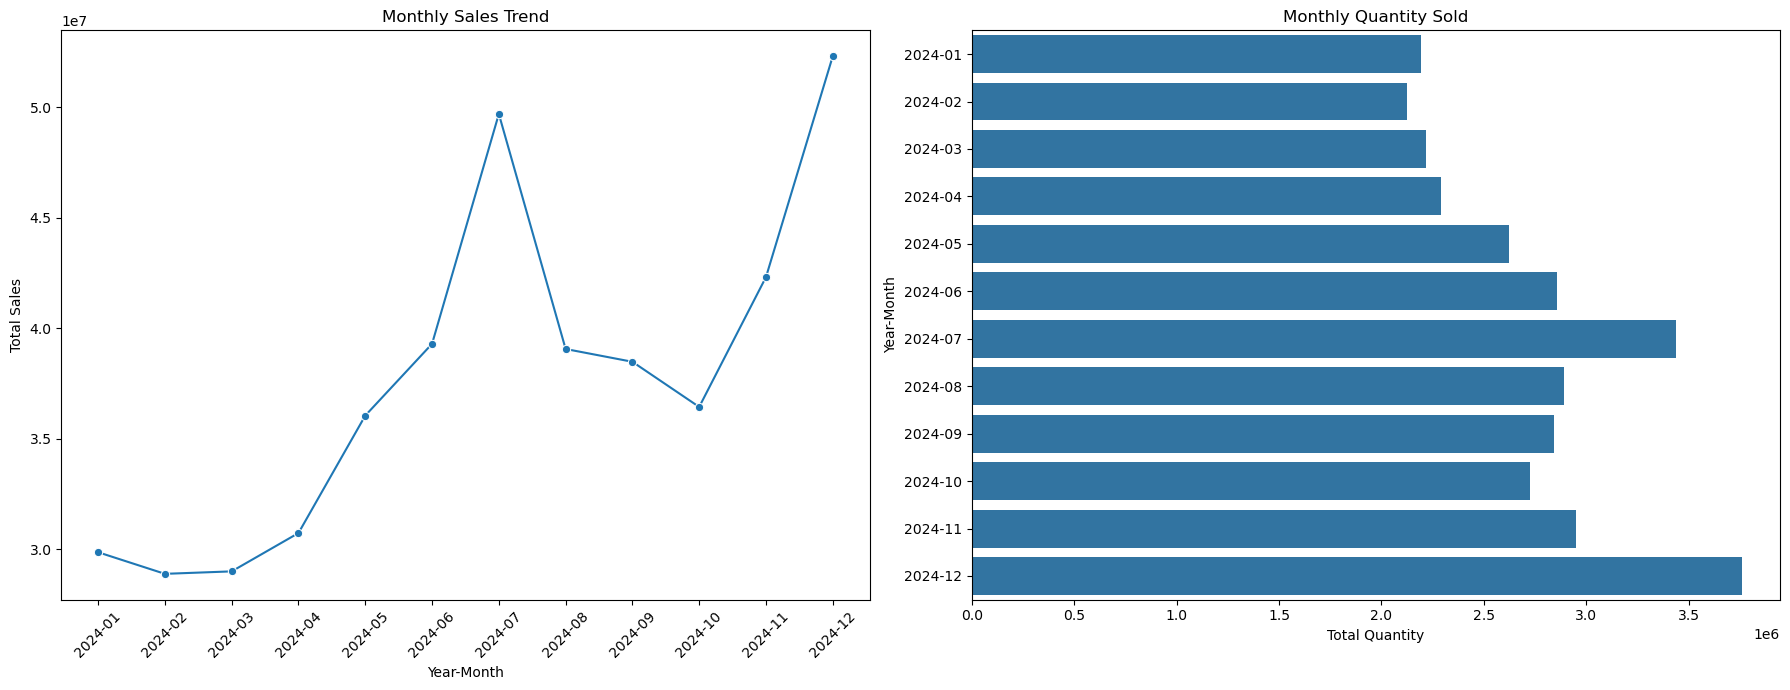

In [14]:

monthly_sales = (
    sales.groupby("SalesYearMonth", as_index=False)
    .agg(
        TotalSales=("SalesDollars", "sum"),
        TotalQuantity=("SalesQuantity", "sum")
    )
)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=monthly_sales,
    x="SalesYearMonth",
    y="TotalSales",
    marker="o",
    ax=ax[0]
)

sns.barplot(
    data=monthly_sales,
    y="SalesYearMonth",
    x="TotalQuantity",
    ax=ax[1]
)

ax[0].set_title("Monthly Sales Trend")
ax[0].set_xlabel("Year-Month")
ax[0].set_ylabel("Total Sales")

ax[1].set_title("Monthly Quantity Sold")
ax[1].set_xlabel("Total Quantity")
ax[1].set_ylabel("Year-Month")

ax[0].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

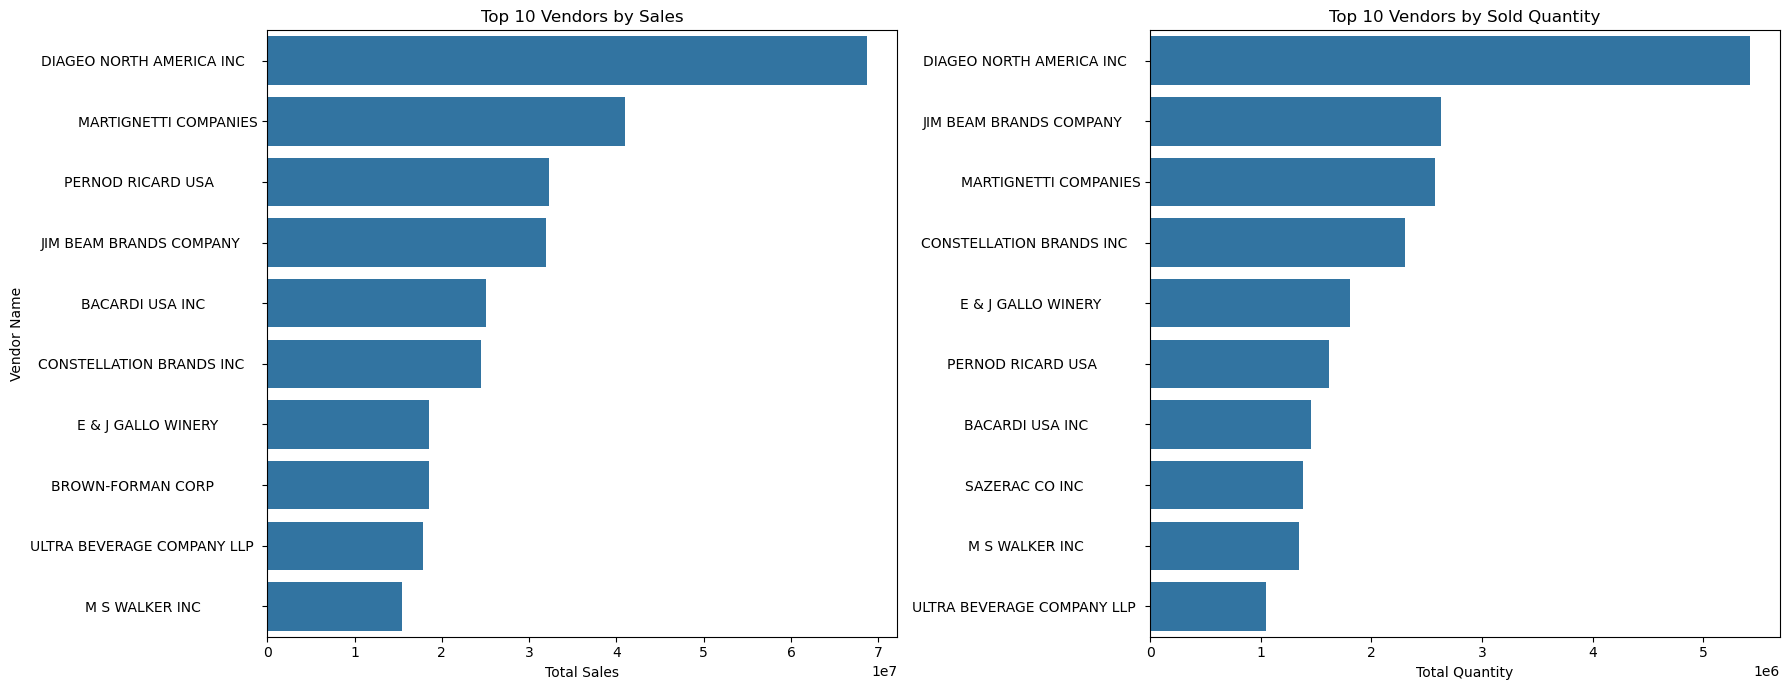

In [16]:

top_vendors_sales = (
    sales.groupby("VendorName", as_index=False)
    .agg(
        TotalSales=("SalesDollars", "sum")
    )
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

top_vendors_sales_quantity = (
    sales.groupby("VendorName", as_index=False)
    .agg(
        TotalQuantity=("SalesQuantity", "sum")
    )
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)


fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Total Sales horizontal bar chart
sns.barplot(
    data=top_vendors_sales,
    x="TotalSales",
    y="VendorName",
    ax=ax[0]
)

ax[0].set_title("Top 10 Vendors by Sales")
ax[0].set_xlabel("Total Sales")
ax[0].set_ylabel("Vendor Name")

# Total Quantity horizontal bar chart
sns.barplot(
    data=top_vendors_sales_quantity,
    x="TotalQuantity",
    y="VendorName",
    ax=ax[1]
)

ax[1].set_title("Top 10 Vendors by Sold Quantity")
ax[1].set_xlabel("Total Quantity")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [56]:
top_products_sales = (
    sales.groupby(["Brand", "Description"], as_index=False)
    .agg(
        TotalSales=("SalesDollars", "sum"),
        TotalQuantity=("SalesQuantity", "sum")
    )
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

top_products_sales

,Brand,Description,TotalSales,TotalQuantity
609,1233,Jack Daniels No 7 Black,5101919.51,142049
1715,3405,Tito's Handmade Vodka,4819073.49,160247
3302,8068,Absolut 80 Proof,4538120.60,187140
2232,4261,Capt Morgan Spiced Rum,4475972.88,200412
1802,3545,Ketel One Vodka,4223107.62,135838
2014,3858,Grey Goose Vodka,3383912.40,141860
1194,2589,Jameson Irish Whiskey,2773367.73,69627
1769,3489,Tanqueray,2640491.19,90481
1539,3102,Smirnoff Traveler,2592041.35,148265
672,1376,Jim Beam,2435393.39,107061


In [57]:
top_vendors_purchase = (
    purchases.groupby("VendorName", as_index=False)
    .agg(
        TotalPurchaseDollars=("Dollars", "sum"),
        TotalPurchaseQuantity=("Quantity", "sum")
    )
    .sort_values("TotalPurchaseDollars", ascending=False)
    .head(10)
)

top_vendors_purchase

,VendorName,TotalPurchaseDollars,TotalPurchaseQuantity
28,DIAGEO NORTH AMERICA INC,50959796.85,5459788
63,MARTIGNETTI COMPANIES,27821473.91,2637275
50,JIM BEAM BRANDS COMPANY,24203151.05,2737165
75,PERNOD RICARD USA,24124091.56,1647558
8,BACARDI USA INC,17624378.72,1427075
23,CONSTELLATION BRANDS INC,15573917.90,2325892
14,BROWN-FORMAN CORP,13529433.08,1006122
115,ULTRA BEVERAGE COMPANY LLP,13210613.93,1077527
33,E & J GALLO WINERY,12289608.09,1858260
59,M S WALKER INC,10935817.30,1372841


In [58]:
freight_by_vendor = (
    vendor_invoice.groupby("VendorName", as_index=False)
    .agg(
        TotalFreight=("Freight", "sum"),
        InvoiceDollars=("Dollars", "sum")
    )
)

freight_by_vendor["FreightPct"] = (
    freight_by_vendor["TotalFreight"] / freight_by_vendor["InvoiceDollars"] * 100
).round(2)

freight_by_vendor.sort_values("TotalFreight", ascending=False).head(10)

,VendorName,TotalFreight,InvoiceDollars,FreightPct
28,DIAGEO NORTH AMERICA INC,257032.07,50959796.85,0.50
63,MARTIGNETTI COMPANIES,144719.92,27821473.91,0.52
50,JIM BEAM BRANDS COMPANY,123880.97,24203151.05,0.51
75,PERNOD RICARD USA,123780.22,24124091.56,0.51
8,BACARDI USA INC,89286.27,17624378.72,0.51
23,CONSTELLATION BRANDS INC,79528.99,15573917.90,0.51
14,BROWN-FORMAN CORP,68601.68,13529433.08,0.51
115,ULTRA BEVERAGE COMPANY LLP,68054.70,13210613.93,0.52
33,E & J GALLO WINERY,61966.91,12289608.09,0.50
59,M S WALKER INC,55551.82,10935817.30,0.51


## Export cleaned data

In [59]:
sales.to_csv("cleaned_data/clean_sales.csv", index=False)
purchases.to_csv("cleaned_data/clean_purchases.csv", index=False)
purchase_prices.to_csv("cleaned_data/clean_purchase_prices.csv", index=False)
vendor_invoice.to_csv("cleaned_data/clean_vendor_invoice.csv", index=False)
begin_inventory.to_csv("cleaned_data/clean_begin_inventory.csv", index=False)
end_inventory.to_csv("cleaned_data/clean_end_inventory.csv", index=False)
data_summary.to_csv("cleaned_data/data_quality_summary.csv", index=False)